#### 대여소별 수요 회귀 모델 (1년치)

- `data/서울특별시 공공자전거 이용정보(시간대별)_*.csv` — 작년 7월 ~ 올해 6월, 월별로 나뉜 12개 파일
- `data/공공자전거 대여소 정보(26.6월 기준).xlsx` — 대여소 번호별 위치/거치대 수 (대여소 번호로만 조인해서 피처 추가)
- `data/weather/*.csv` — 기상청에서 받은 같은 1년 구간의 시간별 관측 데이터 (기온/강수량/풍속/습도)


1. 대여소 수요 모델 — "이 대여소가, 이 시간대에, 평소 몇 건 정도 대여되는지" (요일·시간·대여소 패턴, 날씨 미포함)
2. 날씨 효과 모델 — "오늘 날씨가 평소 대비 전체 대여량을 몇 배로 만드는지" (도시 전체 총량 기준)


#### 1. 라이브러리 

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib

pd.set_option('display.max_columns', None)

#### 2. 데이터 불러오기 대여소별 이용 시간대별

In [34]:
import glob

usage_files = sorted(glob.glob('../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_*.csv'))
print(f'{len(usage_files)}개 파일 발견')
for f in usage_files:
    print(' -', f)

# 12개월치를 전부 이어붙이기 전에, 컬럼 구성이 매달 동일한지 먼저 확인합니다.
# (연도가 바뀌는 시점에 컬럼명/순서가 달라지는 경우가 종종 있어서, 여기서 미리 검증)
column_sets = {}
for f in usage_files:
    try:
        head = pd.read_csv(f, encoding='cp949', nrows=5)
    except UnicodeDecodeError:
        head = pd.read_csv(f, encoding='utf-8', nrows=5)
    column_sets[f] = tuple(head.columns)

unique_column_sets = set(column_sets.values())
print(f'\n서로 다른 컬럼 구성 종류: {len(unique_column_sets)}개')
if len(unique_column_sets) > 1:
    print('⚠️ 파일마다 컬럼 구성이 다릅니다. 아래에서 어떤 파일이 다른지 확인하세요.')
    for f, cols in column_sets.items():
        print(f, '->', cols)
else:
    print('모든 파일의 컬럼 구성이 동일합니다:', list(unique_column_sets)[0])

12개 파일 발견
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202507.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202508.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202509.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202510.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202511.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202512.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202601.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202602.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202603.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202604.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202605.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202606.csv

서로 다른 컬럼 구성 종류: 1개
모든 파일의 컬럼 구성이 동일합니다: ('대여일자', '대여시간', '대여소번호', '대여소명', '대여구분코드', '성별', '연령대코드', '이용건수', '운동량', '탄소량', '이동거리(M)', '이용시간(분)')


In [35]:
def _read_usage_csv(path):
    for enc in ('cp949', 'utf-8'):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError('cp949/utf-8 둘 다 실패', b'', 0, 1, path)

frames = [_read_usage_csv(f) for f in usage_files]
usage = pd.concat(frames, ignore_index=True)

# 월 파일 경계에 겹치는 행이 있을 수 있으니 완전 중복 행 제거
before = len(usage)
usage = usage.drop_duplicates()
print(f'중복 제거: {before}행 -> {len(usage)}행')
print('전체 기간:', usage['대여일자'].min(), '~', usage['대여일자'].max())
usage.shape

중복 제거: 34387753행 -> 34387753행
전체 기간: 2025-07-01 ~ 2026-06-30


(34387753, 12)

In [36]:
print('행/열:', usage.shape)
usage.info()

행/열: (34387753, 12)
<class 'pandas.DataFrame'>
RangeIndex: 34387753 entries, 0 to 34387752
Data columns (total 12 columns):
 #   Column   Dtype  
---  ------   -----  
 0   대여일자     str    
 1   대여시간     int64  
 2   대여소번호    int64  
 3   대여소명     str    
 4   대여구분코드   str    
 5   성별       str    
 6   연령대코드    str    
 7   이용건수     int64  
 8   운동량      str    
 9   탄소량      str    
 10  이동거리(M)  float64
 11  이용시간(분)  int64  
dtypes: float64(1), int64(4), str(7)
memory usage: 3.1 GB


#### 3. 데이터 불러오기 - 대여소

In [37]:
# 원본 엑셀의 '진짜' 컬럼을 먼저 있는 그대로 확인 (추측/가정 없이)
# header=3 위의 실제 헤더 행에 위도/경도, 동 단위 주소가 별도 컬럼으로 있는지 여기서 직접 확인합니다.
raw_station = pd.read_excel('../data/공공자전거 대여소 정보(26.6월 기준).xlsx', header=3)
print('원본 컬럼 목록:', list(raw_station.columns))
raw_station.head(10)

원본 컬럼 목록: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', '거치\n대수', '거치\n대수.1', 'Unnamed: 9']


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,거치\n대수,거치\n대수.1,Unnamed: 9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,102.0,망원역 1번출구 앞,마포구,서울특별시 마포구 월드컵로 72,37.555649,126.910629,2015-09-06 23:42:06,NaN,15.0,QR
2,103.0,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,NaN,14.0,QR
3,104.0,합정역 1번출구 앞,마포구,서울특별시 마포구 양화로 59,37.550629,126.914986,2015-09-06 23:44:31,NaN,13.0,QR
4,105.0,합정역 5번출구 앞,마포구,서울특별시 마포구 양화로 48,37.550007,126.914825,2015-09-06 23:45:30,NaN,5.0,QR
5,106.0,합정역 7번출구 앞,마포구,서울특별시 마포구 독막로 4,37.548645,126.912827,2015-09-06 23:46:31,NaN,12.0,QR
6,107.0,신한은행 서교동지점,마포구,서울특별시 마포구 월드컵북로 35,37.557510,126.918503,2015-09-06 23:47:57,NaN,5.0,QR
7,108.0,서교동 사거리,마포구,서울특별시 마포구 양화로 93,37.552746,126.918617,2015-09-06 23:51:25,NaN,10.0,QR
8,111.0,상수역 2번출구 앞,마포구,서울특별시 마포구 와우산로 40,37.547871,126.923531,2015-09-07 01:30:37,NaN,10.0,QR
9,113.0,홍대입구역 2번출구 앞,마포구,서울특별시 마포구 양화로 165,37.557438,126.923821,2015-09-07 01:32:58,NaN,25.0,QR


In [38]:
# ↑ 출력된 원본 컬럼명을 그대로 써서 매핑합니다 (임의로 만들지 않고, 실제 존재하는 컬럼만 이름만 정리).
# 주의: 아래 컬럼 개수/순서는 위 출력 결과를 보고 실제 컬럼 수에 맞게 반드시 조정해야 합니다.
# ===== 수정: 실행 결과로 확인됨 -> 'addr2'/'addr3'는 사실 주소가 아니라 위도/경도였음.
# 이름을 정확하게 latitude/longitude로 바로잡음 (station_master 저장 시 빠지지 않도록) =====
station = raw_station.copy()
station.columns = ['station_id','station_name','district','road_address','latitude','longitude',
                    'install_date','install_type','rack_count','operation_type']
station = station.dropna(subset=['station_id'])
station['station_id'] = station['station_id'].astype(int)

# 주소 원문 샘플을 직접 눈으로 확인 (동 이름이 어느 컬럼/어느 위치에 있는지 정제 전에 검증)
station[['station_id','station_name','district','road_address','latitude','longitude']].sample(15, random_state=1)

,station_id,station_name,district,road_address,latitude,longitude
232,394,경희궁 자이 3단지,종로구,서울특별시 종로구 경교장길 35 경희궁자이 3단지,37.567490,126.965919
1883,3586,군자역 비채온 오피스텔,광진구,서울특별시 광진구 군자동 473-26,37.557713,127.077271
956,1418,새솔초등학교,중랑구,서울특별시 중랑구 신내역로1길 164 새솔초등학교,37.617439,127.109016
686,1037,강일리버파크 6단지,강동구,서울특별시 강일동 448-2,37.562565,127.177612
1021,1525,미아동 복합청사,강북구,서울특별시 강북구 솔매로49길 14 미아동 195-1,37.627140,127.026695
1551,2396,영동3교 북단(우성캐릭터 앞 보도),강남구,강남구 도곡동 466,37.485741,127.051048
969,1435,능산삼거리,중랑구,서울특별시 중랑구 용마산로 644 능산삼거리,37.608681,127.100792
1711,2809,항동지구 11단지 1103동 앞,구로구,구로구 항동 169-1,37.477905,126.823112
2388,4573,두산위브아파트,영등포구,영등포구 신길로60나길 9,37.514702,126.912140
2550,4873,개롱역사거리 2번 출구,송파구,송파구 오금동 166,37.498272,127.134865


#### 6-1. '동' 추출 (외부 API/임의 CSV 없이, 원본 주소 컬럼에서 직접 파싱)

In [39]:
import re

def extract_dong(addr):
    """도로명주소 문자열에서 법정동/행정동 이름을 정규식으로 추출합니다.
    예: '서울특별시 강동구 암사동 123-4' -> '암사동'
    ⚠️ 실행 결과 성공률이 낮게 나올 수 있습니다 (도로명주소는 원래 '동'을 안 씀 -
    '~로/~길'만 있는 경우가 대부분). 아래 셀에서 실제 성공률을 확인하세요.
    """
    if pd.isna(addr):
        return None
    match = re.search(r'([가-힣]{1,6}\d?동)(?=\s|$)', str(addr))
    return match.group(1) if match else None

station['dong'] = station['road_address'].apply(extract_dong)

print('동 추출 성공률:', station['dong'].notna().mean().__round__(3))
station[station['dong'].isna()][['station_id','station_name','road_address']].head(10)

동 추출 성공률: 0.347


,station_id,station_name,road_address
1,102,망원역 1번출구 앞,서울특별시 마포구 월드컵로 72
2,103,망원역 2번출구 앞,서울특별시 마포구 월드컵로 79
3,104,합정역 1번출구 앞,서울특별시 마포구 양화로 59
4,105,합정역 5번출구 앞,서울특별시 마포구 양화로 48
5,106,합정역 7번출구 앞,서울특별시 마포구 독막로 4
6,107,신한은행 서교동지점,서울특별시 마포구 월드컵북로 35
7,108,서교동 사거리,서울특별시 마포구 양화로 93
8,111,상수역 2번출구 앞,서울특별시 마포구 와우산로 40
9,113,홍대입구역 2번출구 앞,서울특별시 마포구 양화로 165
10,114,홍대입구역 8번출구 앞,서울특별시 마포구 양화로18길 3


**확인 결과 (실행 완료)**:
- `addr2`/`addr3`는 실제로는 위도/경도였음 → `latitude`/`longitude`로 이름 수정 완료
- `road_address`(도로명주소)만으로 동을 추출한 성공률은 **34.7%** — 도로명주소 체계 자체가 법정동을 안 쓰기 때문에
  구조적으로 낮게 나오는 게 정상입니다. 나머지 65.3%는 `dong`이 없는 채로 남습니다.
- 완전히 채우려면 위경도 기반 역지오코딩(법정동 경계 파일)이 필요합니다 — 아직 별도 파일을 못 받아서 보류 중입니다.
  일단은 34.7%만이라도 채워진 상태로 진행하고, 경계 파일을 받으면 이 부분만 다시 채워드릴게요.

#### 4. EDA

In [40]:
usage.isnull().sum()

대여일자             0
대여시간             0
대여소번호            0
대여소명             0
대여구분코드           0
성별         8683597
연령대코드            0
이용건수             0
운동량              0
탄소량              0
이동거리(M)          0
이용시간(분)          0
dtype: int64

/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/

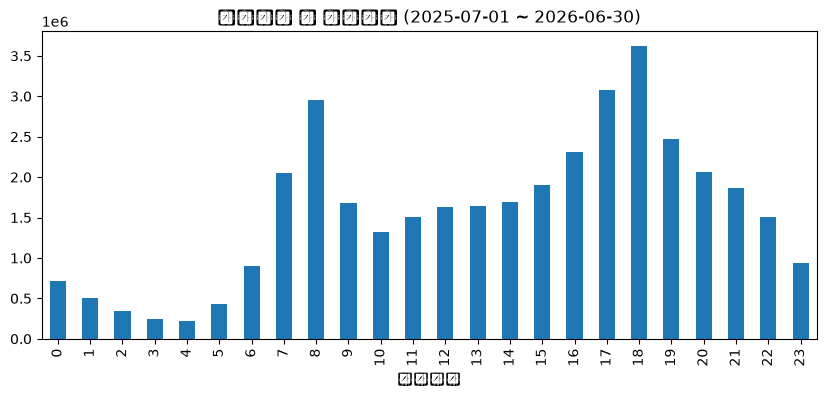

In [41]:
# 시간대별 총 이용건수
hourly = usage.groupby('대여시간')['이용건수'].sum()
plt.figure(figsize=(10,4))
hourly.plot(kind='bar')
# ===== 수정: 6월 한정 제목을 실제 학습 기간 표시로 변경 =====
plt.title(f"시간대별 총 이용건수 ({usage['대여일자'].min()} ~ {usage['대여일자'].max()})")
# ===== 수정 끝 =====
plt.show()

In [42]:
station['rack_count'].describe()

count    1740.000000
mean       11.866667
std         6.058516
min         2.000000
25%         9.000000
50%        10.000000
75%        14.000000
max        62.000000
Name: rack_count, dtype: float64

#### 5. 전처리: 날짜+시간+대여소로 이용건수 합산

In [43]:
# 성별/연령대/대여구분 등으로 잘게 나뉜 로그를 (날짜, 시간, 대여소) 단위로 합산
agg = usage.groupby(['대여일자','대여시간','대여소번호'], as_index=False)['이용건수'].sum()
agg.columns = ['date','hour','station_id','rental_count']
agg.head()

,date,hour,station_id,rental_count
0,2025-07-01,0,103,4
1,2025-07-01,0,104,1
2,2025-07-01,0,107,1
3,2025-07-01,0,111,3
4,2025-07-01,0,113,4


#### 6. 전처리: '이용 0건'인 시간대도 포함시키기
대여 로그에는 실제로 이용이 있었던 (날짜, 시간, 대여소) 조합만 있고, 이용이 0건인 조합은 아예 행이 없어요.
이걸 그대로 학습하면 모델이 '0건'인 경우를 한 번도 못 보고 항상 과대예측하게 되니, 전체 조합 그리드를 만들어서 없는 조합은 0으로 채웁니다.

In [ ]:
stations = agg['station_id'].unique()
# ===== 수정: 6월 한 달로 고정되어 있던 것을, 실제 데이터의 최소~최대 날짜로 자동 확장 =====
dates = pd.date_range(agg['date'].min(), agg['date'].max()).strftime('%Y-%m-%d')
# ===== 수정 끝 =====
hours = range(24)

grid = pd.MultiIndex.from_product([stations, dates, hours],
                                    names=['station_id','date','hour']).to_frame(index=False)
full = grid.merge(agg, on=['station_id','date','hour'], how='left')
full['rental_count'] = full['rental_count'].fillna(0).astype(int)
print(full.shape)
full.head()

(24720720, 4)


,station_id,date,hour,rental_count
0,103,2025-07-01,0,4
1,103,2025-07-01,1,6
2,103,2025-07-01,2,2
3,103,2025-07-01,3,1
4,103,2025-07-01,4,0


#### 7. 대여소 마스터와 조인 (거치대 수, 지역구 피처 추가)

In [45]:
full = full.merge(station, on='station_id', how='left')
full['rack_count'] = full['rack_count'].fillna(full['rack_count'].median())
full['district'] = full['district'].fillna('알수없음')
full['dong'] = full['dong'].fillna('알수없음')

full['date'] = pd.to_datetime(full['date'])
full['day_of_week'] = full['date'].dt.dayofweek
full['is_weekend'] = (full['day_of_week'] >= 5).astype(int)
# ===== 추가: 이제 1년치라 계절성이 존재함 -> month를 피처로 추가 =====
# (6월 한 달만 있을 땐 이 피처가 상수라서 의미가 없었지만, 1년치가 되면서 유의미해짐)
full['month'] = full['date'].dt.month
# ===== 추가 끝 =====
full.head()

,station_id,date,hour,rental_count,station_name,district,road_address,latitude,longitude,install_date,install_type,rack_count,operation_type,dong,day_of_week,is_weekend,month
0,103,2025-07-01,0,4,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,NaN,14.0,QR,알수없음,1,0,7
1,103,2025-07-01,1,6,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,NaN,14.0,QR,알수없음,1,0,7
2,103,2025-07-01,2,2,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,NaN,14.0,QR,알수없음,1,0,7
3,103,2025-07-01,3,1,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,NaN,14.0,QR,알수없음,1,0,7
4,103,2025-07-01,4,0,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,NaN,14.0,QR,알수없음,1,0,7


#### 8. 범주형 인코딩

In [46]:
le = LabelEncoder()
full['district_enc'] = le.fit_transform(full['district'])

#### 9. 학습/검증 데이터 분리

In [47]:
features = ['station_id','hour','day_of_week','is_weekend','rack_count','district_enc','month']
X = full[features]
y = full['rental_count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(19776576, 7) (4944144, 7)


#### 10. RandomForest 회귀 모델 학습

In [48]:
# ===== 수정: 약 2,478만 행(RandomForest엔 너무 큼) -> HistGradientBoostingRegressor로 교체 =====
# 히스토그램 기반이라 이 정도 규모에서 RandomForest보다 훨씬 빠르고 메모리도 적게 씁니다.
model = HistGradientBoostingRegressor(
    max_iter=150, max_depth=10, min_samples_leaf=20,
    random_state=42
)
model.fit(X_train, y_train)
# ===== 수정 끝 =====
# 참고: HistGradientBoostingRegressor에는 feature_names_in_가 X_train이 DataFrame이면 자동으로 붙습니다.
# (ai_station.py에서 model.feature_names_in_로 컬럼 순서 맞추는 부분 그대로 동작함)

,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",150
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",10
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


#### 11. 모델 평가

In [49]:
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
print(f'MAE: {mae:.3f}')
print(f'R2 Score: {r2:.4f}')

# 참고: 대여소·시간 단위 이용건수는 중앙값이 1건일 정도로 변동성이 커서
# R2가 낮게 나오는 게 정상입니다 (날씨 데이터가 없는 상태의 순수 패턴 모델).


MAE: 1.368
R2 Score: 0.3366


/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/de

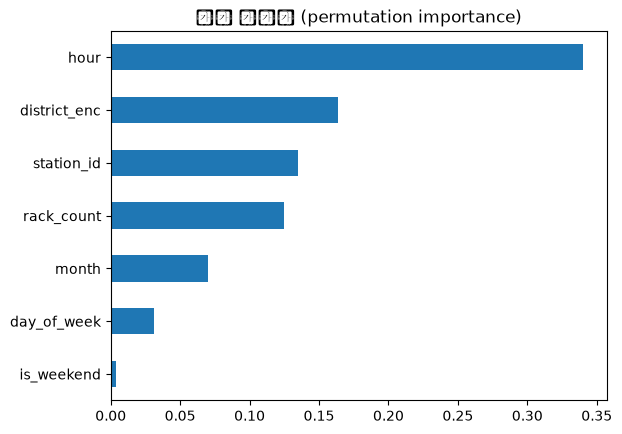

In [50]:
# ===== 수정: HistGradientBoostingRegressor는 RandomForest와 달리 feature_importances_가 없음 =====
# -> permutation_importance로 대체. 494만 행 전체로 하면 느리니 2만 행만 샘플링해서 계산.
sample_idx = X_test.sample(20000, random_state=42).index
perm = permutation_importance(
    model, X_test.loc[sample_idx], y_test.loc[sample_idx],
    n_repeats=5, random_state=42, n_jobs=-1
)
importance = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)
importance.plot(kind='barh')
plt.title('피처 중요도 (permutation importance)')
plt.gca().invert_yaxis()
plt.show()
# ===== 수정 끝 =====

#### 12. 모델 저장

In [51]:
import os
os.makedirs('../models', exist_ok=True)

period_tag = f"{full['date'].min().strftime('%Y%m')}_{full['date'].max().strftime('%Y%m')}"
print('학습 기간 태그:', period_tag)

joblib.dump(model, f'../models/station_demand_model_{period_tag}.pkl')
joblib.dump(le, f'../models/district_encoder_{period_tag}.pkl')

# ===== 수정: latitude/longitude가 빠져있던 버그 수정 -> 반드시 포함해서 저장 =====
# (ai_station.py가 인근 대여소 거리 계산과 응답 스키마에 latitude/longitude를 필수로 씀)
station_master = station[
    ['station_id', 'station_name', 'district', 'dong', 'latitude', 'longitude', 'rack_count']
].drop_duplicates(subset='station_id')
# ===== 수정 끝 =====
station_master.to_csv(f'../models/station_master_{period_tag}.csv', index=False)
print('저장 완료 (대여소 수요 모델)')
print('결측 확인:')
print(station_master.isnull().sum())
station_master.sample(10, random_state=1)

학습 기간 태그: 202507_202606
저장 완료 (대여소 수요 모델)
결측 확인:
station_id         0
station_name       0
district           0
dong            1820
latitude           0
longitude          0
rack_count      1049
dtype: int64


,station_id,station_name,district,dong,latitude,longitude,rack_count
232,394,경희궁 자이 3단지,종로구,NaN,37.567490,126.965919,15.0
1883,3586,군자역 비채온 오피스텔,광진구,군자동,37.557713,127.077271,8.0
956,1418,새솔초등학교,중랑구,NaN,37.617439,127.109016,NaN
686,1037,강일리버파크 6단지,강동구,강일동,37.562565,127.177612,NaN
1021,1525,미아동 복합청사,강북구,미아동,37.627140,127.026695,NaN
1551,2396,영동3교 북단(우성캐릭터 앞 보도),강남구,도곡동,37.485741,127.051048,NaN
969,1435,능산삼거리,중랑구,NaN,37.608681,127.100792,NaN
1711,2809,항동지구 11단지 1103동 앞,구로구,항동,37.477905,126.823112,10.0
2388,4573,두산위브아파트,영등포구,NaN,37.514702,126.912140,10.0
2550,4873,개롱역사거리 2번 출구,송파구,오금동,37.498272,127.134865,7.0


In [52]:
# station = station[['station_id','district','rack_count']].drop_duplicates(subset='station_id')

---
# Part 2. 날씨 효과 모델 (1년치로 재학습, 이 노트북 안에서 투명하게)

이전에는 `weather_effect_model_202606.pkl`이 이 노트북 밖에서 별도로 만들어져서
출처를 검증할 수 없었습니다. 이제부터는 같은 원칙(원본 컬럼을 먼저 그대로 확인한 뒤 매핑)으로
이 노트북 안에서 직접 만듭니다.

필요한 것:
1. 기상청에서 받은 시간별 관측 데이터 (`../data/weather/*.csv` 등)
2. 같은 시간대의 **도시 전체 총 대여건수** — 이건 이미 위에서 만든 `agg`를 시간 단위로 합산하면 바로 나옵니다 (새로 안 받아도 됨)

#### 13. 도시 전체 시간대별 총 대여량 만들기 (Part 1의 `agg` 재사용)

In [53]:
# agg: date, hour, station_id, rental_count (Part 1에서 이미 만든 것)
citywide = agg.groupby(['date','hour'], as_index=False)['rental_count'].sum()
citywide.columns = ['date','hour','total_rentals']
citywide['date'] = pd.to_datetime(citywide['date'])
print(citywide.shape)
citywide.head()

(8760, 3)


,date,hour,total_rentals
0,2025-07-01,0,2753
1,2025-07-01,1,1920
2,2025-07-01,2,1266
3,2025-07-01,3,880
4,2025-07-01,4,864


#### 14. 기상청 원본 데이터 확인 (컬럼명 가정하지 않고 그대로 출력)

In [54]:
# ===== 참고: 파일이 1개(1년치 전부)든 여러 개(월별)든 아래 코드는 그대로 동작합니다 =====
# glob 패턴에 맞는 파일을 찾아서 전부 이어붙이는 방식이라, 파일 개수에 상관없이 동일하게 처리됩니다.
# 파일이 '../data/weather/' 폴더가 아니라 다른 위치/이름이면 아래 패턴만 실제 경로에 맞게 바꿔주세요.
weather_files = sorted(glob.glob('../data/OBS_20250701_20260731.csv'))
print(f'{len(weather_files)}개 날씨 파일 발견')
for f in weather_files:
    print(' -', f)

def _read_weather_csv(path):
    for enc in ('cp949', 'utf-8'):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError('cp949/utf-8 둘 다 실패', b'', 0, 1, path)

raw_weather = pd.concat([_read_weather_csv(f) for f in weather_files], ignore_index=True)
print('\n원본 컬럼 목록:', list(raw_weather.columns))
raw_weather.head(10)

1개 날씨 파일 발견
 - ../data/OBS_20250701_20260731.csv

원본 컬럼 목록: ['지점', '지점명', '일시', '기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)']


,지점,지점명,일시,기온(°C),강수량(mm),풍속(m/s),습도(%)
0,108,서울,2025-07-01 00:00,27.7,NaN,2.6,77
1,108,서울,2025-07-01 01:00,27.4,NaN,2.6,79
2,108,서울,2025-07-01 02:00,27.1,NaN,2.7,81
3,108,서울,2025-07-01 03:00,26.9,NaN,2.6,82
4,108,서울,2025-07-01 04:00,26.7,NaN,3.2,84
5,108,서울,2025-07-01 05:00,26.7,0.0,2.9,84
6,108,서울,2025-07-01 06:00,26.5,0.0,2.0,87
7,108,서울,2025-07-01 07:00,26.4,0.1,2.4,91
8,108,서울,2025-07-01 08:00,26.4,0.8,3.1,91
9,108,서울,2025-07-01 09:00,27.0,0.0,2.7,88


**검증 필요**: 위 셀 출력을 보고 아래 컬럼 매핑을 실제 컬럼명에 맞게 고치세요.
기상청 종관기상관측(ASOS) 시간자료의 전형적인 컬럼은
`일시`(관측시각), `기온(°C)`, `강수량(mm)`, `풍속(m/s)`, `습도(%)` 형태입니다만,
지점명이 같이 있거나 컬럼 순서가 다를 수 있으니 위 출력과 반드시 대조하세요.

In [55]:
# ===== 아래 딕셔너리의 '원본 컬럼명' 부분을, 바로 위 셀에서 출력된 실제 컬럼명으로 바꿔주세요 =====
COLUMN_MAP = {
    '일시': 'datetime',
    '기온(°C)': 'temperature',
    '강수량(mm)': 'rainfall',
    '풍속(m/s)': 'wind_speed',
    '습도(%)': 'humidity',
}

missing = [k for k in COLUMN_MAP if k not in raw_weather.columns]
if missing:
    print('⚠️ 아래 컬럼을 원본에서 못 찾았습니다. COLUMN_MAP을 위 원본 컬럼 목록에 맞게 수정하세요:', missing)
else:
    weather = raw_weather[list(COLUMN_MAP.keys())].rename(columns=COLUMN_MAP)
    weather['datetime'] = pd.to_datetime(weather['datetime'])
    weather['date'] = weather['datetime'].dt.strftime('%Y-%m-%d')
    weather['date'] = pd.to_datetime(weather['date'])
    weather['hour'] = weather['datetime'].dt.hour
    # 결측 관측치(장비 점검 등으로 비는 시간)는 앞뒤 값으로 보간
    weather[['temperature','rainfall','wind_speed','humidity']] = (
    weather[['temperature','rainfall','wind_speed','humidity']].ffill().bfill()
   )
    print(weather.shape)
    weather.head()

(9504, 7)


#### 15. 도시 전체 이용량 + 날씨 병합 (날짜+시간 기준)

In [56]:
weather_full = citywide.merge(weather[['date','hour','temperature','rainfall','wind_speed','humidity']],
                               on=['date','hour'], how='inner')
weather_full['day_of_week'] = weather_full['date'].dt.dayofweek
weather_full['is_weekend'] = (weather_full['day_of_week'] >= 5).astype(int)

print(f'병합 전 이용량 데이터: {len(citywide)}행, 병합 후: {len(weather_full)}행')
if len(weather_full) < len(citywide) * 0.9:
    print('⚠️ 병합 후 행이 많이 줄었습니다 — 이용 로그 기간과 날씨 데이터 기간이 서로 안 맞을 수 있어요.')
    print('이용 로그 기간:', citywide['date'].min(), '~', citywide['date'].max())
    print('날씨 데이터 기간:', weather['date'].min(), '~', weather['date'].max())

weather_full.head()

병합 전 이용량 데이터: 8760행, 병합 후: 8760행


,date,hour,total_rentals,temperature,rainfall,wind_speed,humidity,day_of_week,is_weekend
0,2025-07-01,0,2753,27.7,0.0,2.6,77,1,0
1,2025-07-01,1,1920,27.4,0.0,2.6,79,1,0
2,2025-07-01,2,1266,27.1,0.0,2.7,81,1,0
3,2025-07-01,3,880,26.9,0.0,2.6,82,1,0
4,2025-07-01,4,864,26.7,0.0,3.2,84,1,0


#### 16. 날씨 효과 모델 학습

In [57]:
weather_features = ['hour','day_of_week','is_weekend','temperature','rainfall','wind_speed','humidity']
Xw = weather_full[weather_features]
yw = weather_full['total_rentals']

Xw_train, Xw_test, yw_train, yw_test = train_test_split(Xw, yw, test_size=0.2, random_state=42)

weather_model = RandomForestRegressor(
    n_estimators=150, max_depth=12, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
weather_model.fit(Xw_train, yw_train)

wpred = weather_model.predict(Xw_test)
print(f'날씨 모델 MAE: {mean_absolute_error(yw_test, wpred):.2f}')
print(f'날씨 모델 R2: {r2_score(yw_test, wpred):.4f}')

날씨 모델 MAE: 618.12
날씨 모델 R2: 0.9040


#### 17. 학습 범위 직접 확인 (지난번처럼 '조용히 뭉개지는 구간'이 남아있는지 점검)

1년치로 늘었으니 이전(22~32℃만 반응)보다 범위가 넓어졌는지, 온도를 촘촘히 훑어서 직접 확인합니다.

In [58]:
probe_hour, probe_dow = 18, 2
for t in range(int(weather_full['temperature'].min()) - 5, int(weather_full['temperature'].max()) + 6, 2):
    row = pd.DataFrame([{
        'hour': probe_hour, 'day_of_week': probe_dow, 'is_weekend': 0,
        'temperature': t, 'rainfall': 0, 'wind_speed': 2.0, 'humidity': 50,
    }])
    pred = weather_model.predict(row[weather_features])[0]
    print(f'{t:>4}℃ -> {pred:.1f}')

print('\n실제 학습 데이터의 기온 범위:', weather_full['temperature'].min(), '~', weather_full['temperature'].max())

 -18℃ -> 4660.4
 -16℃ -> 4660.4
 -14℃ -> 4660.4
 -12℃ -> 4660.4
 -10℃ -> 4651.9
  -8℃ -> 4669.5
  -6℃ -> 4704.8
  -4℃ -> 4966.4
  -2℃ -> 5184.9
   0℃ -> 5705.2
   2℃ -> 6975.3
   4℃ -> 7178.3
   6℃ -> 8845.6
   8℃ -> 9532.4
  10℃ -> 10028.9
  12℃ -> 12999.5
  14℃ -> 13880.1
  16℃ -> 13993.8
  18℃ -> 14736.5
  20℃ -> 14844.6
  22℃ -> 15232.4
  24℃ -> 16332.2
  26℃ -> 16166.9
  28℃ -> 16138.9
  30℃ -> 16101.1
  32℃ -> 15574.4
  34℃ -> 15161.2
  36℃ -> 15133.5
  38℃ -> 15133.5
  40℃ -> 15133.5
  42℃ -> 15133.5

실제 학습 데이터의 기온 범위: -13.1 ~ 37.6


#### 18. 날씨 없는 기준선(baseline) 재계산 — hour × is_weekend 평균

In [59]:
weather_reference = citywide.copy()
weather_reference['day_of_week'] = weather_reference['date'].dt.dayofweek
weather_reference['is_weekend'] = (weather_reference['day_of_week'] >= 5).astype(int)
weather_reference = (
    weather_reference.groupby(['hour','is_weekend'], as_index=False)['total_rentals'].mean()
)
print(weather_reference.shape)  # 24시간 x 2(평일/주말) = 48행이어야 정상
weather_reference.head()

(48, 3)


,hour,is_weekend,total_rentals
0,0,0,1826.210728
1,0,1,2329.798077
2,1,0,1251.057471
3,1,1,1700.451923
4,2,0,838.187739


#### 19. 날씨 모델 저장

In [60]:
joblib.dump(weather_model, f'../models/weather_effect_model_{period_tag}.pkl')
weather_reference.to_csv(f'../models/weather_reference_{period_tag}.csv', index=False)
print('저장 완료 (날씨 효과 모델):', period_tag)

저장 완료 (날씨 효과 모델): 202507_202606


---
# Part 3. 추가 EDA 
— 월별 이용 추이 / 인기 대여소 TOP 6 / 연령대별 이용 비율

Part 1에서 만든 `usage`(12개월치 원본, 중복 제거 완료)를 그대로 재사용합니다.

#### 21. 월별 이용 추이 (2025년 / 2026년 구분)

/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/

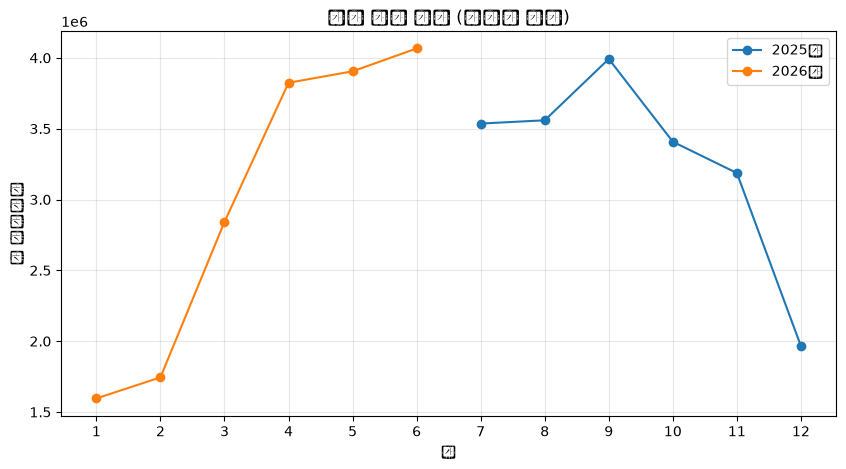

year,2025,2026
month,,
1,NaN,1595794.0
2,NaN,1744655.0
3,NaN,2842132.0
4,NaN,3824050.0
5,NaN,3904989.0
6,NaN,4066383.0
7,3536136.0,NaN
8,3559210.0,NaN
9,3992254.0,NaN


In [61]:
usage['대여일자'] = pd.to_datetime(usage['대여일자'])
usage['year'] = usage['대여일자'].dt.year
usage['month'] = usage['대여일자'].dt.month

monthly = usage.groupby(['year','month'], as_index=False)['이용건수'].sum()
monthly_pivot = monthly.pivot(index='month', columns='year', values='이용건수')

plt.figure(figsize=(10,5))
for year in monthly_pivot.columns:
    plt.plot(monthly_pivot.index, monthly_pivot[year], marker='o', label=f'{year}년')
plt.xlabel('월')
plt.ylabel('총 이용건수')
plt.title('월별 이용 추이 (연도별 비교)')
plt.xticks(range(1,13))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

monthly_pivot

#### 22. 인기 대여소 TOP 6

/var/folders/y7/cnx_3pbd4vg17lq55z4_mk7w0000gn/T/ipykernel_17038/4126312889.py:12: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y7/cnx_3pbd4vg17lq55z4_mk7w0000gn/T/ipykernel_17038/4126312889.py:12: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y7/cnx_3pbd4vg17lq55z4_mk7w0000gn/T/ipykernel_17038/4126312889.py:12: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y7/cnx_3pbd4vg17lq55z4_mk7w0000gn/T/ipykernel_17038/4126312889.py:12: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y7/cnx_3pbd4vg17lq55z4_mk7w0000gn/T/ipykernel_17038/4126312889.py:12: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y7/cnx_3pbd4vg17lq55z4_mk7w0000gn/T/ipyker

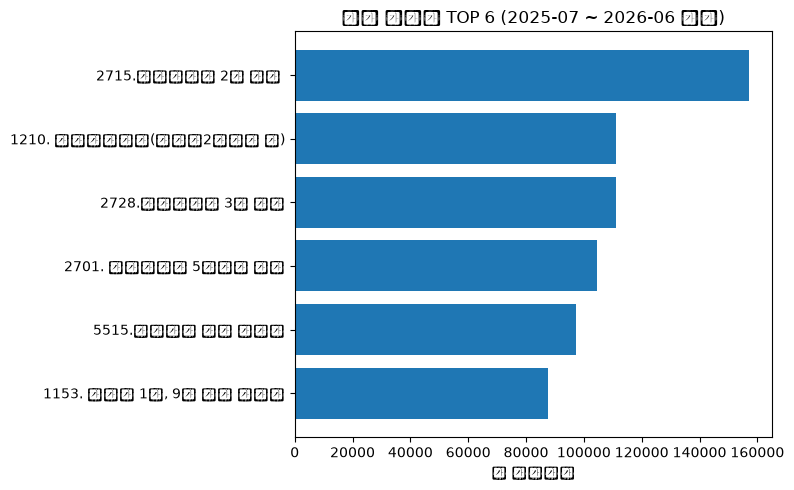

,대여소번호,대여소명,이용건수
1697,2715,2715.마곡나루역 2번 출구,157195
817,1210,1210. 롯데월드타워(잠실역2번출구 쪽),111057
1708,2728,2728.마곡나루역 3번 출구,111042
1685,2701,2701. 마곡나루역 5번출구 뒤편,104600
2728,5515,5515.한강버스 망원 선착장,97178
768,1153,"1153. 발산역 1번, 9번 인근 대여소",87436


In [62]:
top_stations = (
    usage.groupby(['대여소번호','대여소명'], as_index=False)['이용건수']
    .sum()
    .sort_values('이용건수', ascending=False)
    .head(6)
)

plt.figure(figsize=(8,5))
plt.barh(top_stations['대여소명'][::-1], top_stations['이용건수'][::-1])
plt.xlabel('총 이용건수')
plt.title('인기 대여소 TOP 6 (2025-07 ~ 2026-06 누적)')
plt.tight_layout()
plt.show()

top_stations

#### 23. 연령대별 이용 비율

/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-y

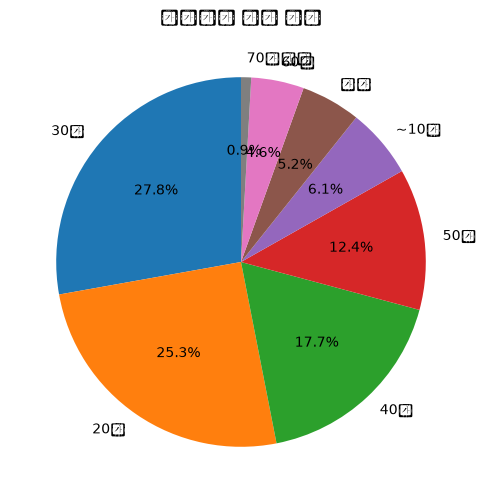

,연령대코드,이용건수,비율(%)
1,30대,10465953,27.8
0,20대,9506023,25.3
2,40대,6676422,17.7
3,50대,4651001,12.4
6,~10대,2294914,6.1
7,기타,1961555,5.2
4,60대,1736043,4.6
5,70대이상,333477,0.9


In [63]:
age_usage = usage.groupby('연령대코드', as_index=False)['이용건수'].sum()
age_usage['비율(%)'] = (age_usage['이용건수'] / age_usage['이용건수'].sum() * 100).round(1)
age_usage = age_usage.sort_values('이용건수', ascending=False)

plt.figure(figsize=(6,6))
plt.pie(age_usage['이용건수'], labels=age_usage['연령대코드'], autopct='%1.1f%%', startangle=90)
plt.title('연령대별 이용 비율')
plt.show()

age_usage

**참고**: `연령대코드`가 원본에서 어떤 형식으로 들어있는지(예: '20대', '2', 'M20' 등)에 따라
그래프 라벨이 이상하게 나올 수 있습니다. 21번 셀 실행 후 `usage['연령대코드'].unique()`로
실제 값 형식을 한 번 확인해보시고, 필요하면 알려주세요 — 라벨을 보기 좋게 다듬어드릴게요.

---
#### 24. 프론트엔드용 집계 결과 저장 (`AIAnalysis.jsx`가 그대로 읽을 수 있는 형태)

서버가 요청마다 3,400만 행짜리 원본 로그를 다시 읽지 않도록, 위에서 만든 3개 집계 결과를
가벼운 JSON 하나로 미리 저장해둡니다. `ai_station.py`는 이 파일만 읽어서 그대로 반환하면 됩니다.

In [64]:
import json as _json

period_label = f"{usage['대여일자'].min().strftime('%Y.%m')} ~ {usage['대여일자'].max().strftime('%Y.%m')}"

# 1) 월별 이용 추이 -> [{month: '2025-07', count: 123}, ...]  (연-월로 표기해서 두 연도 겹침 방지)
monthly_export = usage.groupby(usage['대여일자'].dt.strftime('%Y-%m'), as_index=False)['이용건수'].sum()
monthly_export.columns = ['month', 'count']
monthly_export = monthly_export.sort_values('month')

# 2) 인기 대여소 TOP 6 -> [{name: '...', count: 123}, ...]
# ===== 수정: 대여소명만으로 묶으면 이름이 같은 서로 다른 대여소가 합쳐질 위험이 있어
# 22번 셀과 동일하게 대여소번호+명으로 먼저 묶은 뒤 이름만 남김 =====
top_stations_export = (
    usage.groupby(['대여소번호','대여소명'], as_index=False)['이용건수'].sum()
    .sort_values('이용건수', ascending=False)
    .head(6)[['대여소명','이용건수']]
    .rename(columns={'대여소명': 'name', '이용건수': 'count'})
)

# 3) 연령대별 비율 -> [{age: '20대', percent: 23.5}, ...]
age_export = usage.groupby('연령대코드', as_index=False)['이용건수'].sum()
age_export['percent'] = (age_export['이용건수'] / age_export['이용건수'].sum() * 100).round(1)
age_export = age_export.rename(columns={'연령대코드': 'age'})[['age', 'percent']].sort_values('percent', ascending=False)

# 4) 간단한 인사이트 자동 생성 (숫자 기반, 문구는 필요시 자유롭게 수정하세요)
peak_month = monthly_export.loc[monthly_export['count'].idxmax()]
top1 = top_stations_export.iloc[0]
top_age = age_export.iloc[0]

insights_export = [
    {
        "title": "최다 이용 월",
        "description": f"{peak_month['month']}에 이용량이 가장 많았습니다 ({int(peak_month['count']):,}건).",
    },
    {
        "title": "최고 인기 대여소",
        "description": f"'{top1['name']}'이(가) 가장 많이 이용됐습니다 ({int(top1['count']):,}건).",
    },
    {
        "title": "주 이용 연령대",
        "description": f"'{top_age['age']}' 연령대가 전체 이용의 {top_age['percent']}%를 차지합니다.",
    },
]

analysis_export = {
    "periodLabel": period_label,
    "monthlyUsage": monthly_export.to_dict(orient='records'),
    "topStations": top_stations_export.to_dict(orient='records'),
    "ageDistribution": age_export.to_dict(orient='records'),
    "insights": insights_export,
}

with open(f'../models/analysis_summary_{period_tag}.json', 'w', encoding='utf-8') as f:
    _json.dump(analysis_export, f, ensure_ascii=False, indent=2)

print('저장 완료:', f'../models/analysis_summary_{period_tag}.json')
analysis_export

저장 완료: ../models/analysis_summary_202507_202606.json


{'periodLabel': '2025.07 ~ 2026.06',
 'monthlyUsage': [{'month': '2025-07', 'count': 3536136},
  {'month': '2025-08', 'count': 3559210},
  {'month': '2025-09', 'count': 3992254},
  {'month': '2025-10', 'count': 3407752},
  {'month': '2025-11', 'count': 3186894},
  {'month': '2025-12', 'count': 1965139},
  {'month': '2026-01', 'count': 1595794},
  {'month': '2026-02', 'count': 1744655},
  {'month': '2026-03', 'count': 2842132},
  {'month': '2026-04', 'count': 3824050},
  {'month': '2026-05', 'count': 3904989},
  {'month': '2026-06', 'count': 4066383}],
 'topStations': [{'name': '2715.마곡나루역 2번 출구 ', 'count': 157195},
  {'name': '1210. 롯데월드타워(잠실역2번출구 쪽)', 'count': 111057},
  {'name': '2728.마곡나루역 3번 출구', 'count': 111042},
  {'name': '2701. 마곡나루역 5번출구 뒤편', 'count': 104600},
  {'name': '5515.한강버스 망원 선착장', 'count': 97178},
  {'name': '1153. 발산역 1번, 9번 인근 대여소', 'count': 87436}],
 'ageDistribution': [{'age': '30대', 'percent': 27.8},
  {'age': '20대', 'percent': 25.3},
  {'age': '40대', 'percent':